In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Path setup ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
cleaned_path = os.path.join(project_root, 'data', 'cookie_cats_cleaned.csv')

# --- Load cleaned data ---
df = pd.read_csv(cleaned_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nGroup sizes:")
print(df['version'].value_counts())
print("\nFirst 5 rows:")
df.head()

Shape: (90188, 5)

Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']

Group sizes:
version
gate_40    45489
gate_30    44699
Name: count, dtype: int64

First 5 rows:


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [2]:
# --- Split into groups ---
gate_30 = df[df['version'] == 'gate_30']['sum_gamerounds']
gate_40 = df[df['version'] == 'gate_40']['sum_gamerounds']

# --- Quick summary stats per group ---
summary = pd.DataFrame({
    'gate_30': gate_30.describe(),
    'gate_40': gate_40.describe()
})

print("=== Summary Statistics: sum_gamerounds by Group ===")
print(summary.round(2))

=== Summary Statistics: sum_gamerounds by Group ===
        gate_30   gate_40
count  44699.00  45489.00
mean      51.34     51.30
std      102.06    103.29
min        0.00      0.00
25%        5.00      5.00
50%       17.00     16.00
75%       50.00     52.00
max     2961.00   2640.00


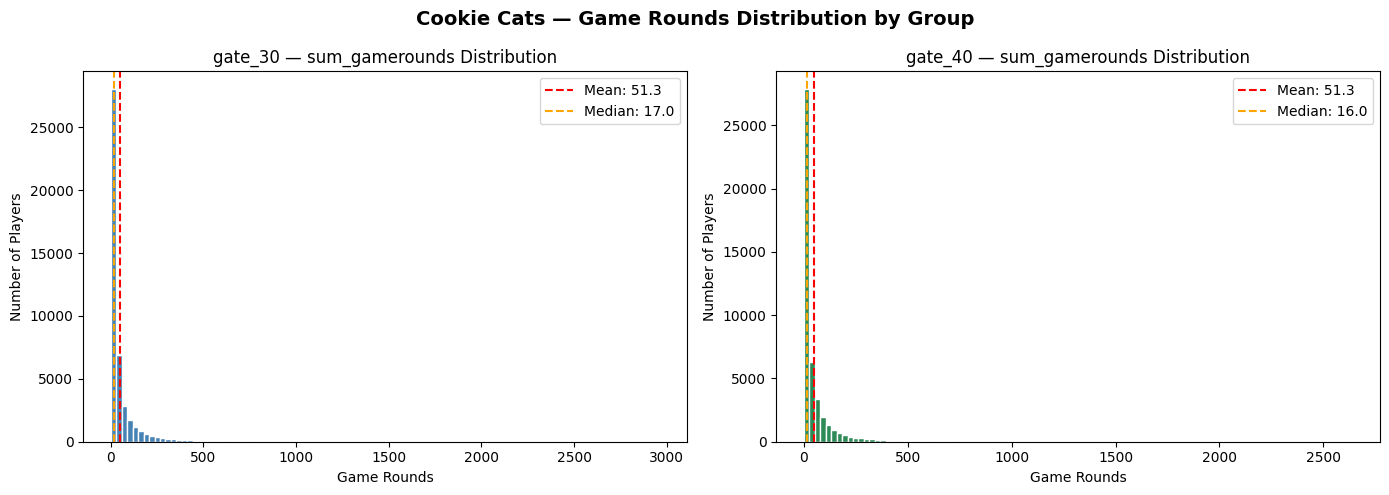

Histogram saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- gate_30 histogram ---
axes[0].hist(gate_30, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('gate_30 — sum_gamerounds Distribution', fontsize=12)
axes[0].set_xlabel('Game Rounds')
axes[0].set_ylabel('Number of Players')
axes[0].axvline(gate_30.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {gate_30.mean():.1f}')
axes[0].axvline(gate_30.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {gate_30.median():.1f}')
axes[0].legend()

# --- gate_40 histogram ---
axes[1].hist(gate_40, bins=100, color='seagreen', edgecolor='white')
axes[1].set_title('gate_40 — sum_gamerounds Distribution', fontsize=12)
axes[1].set_xlabel('Game Rounds')
axes[1].set_ylabel('Number of Players')
axes[1].axvline(gate_40.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {gate_40.mean():.1f}')
axes[1].axvline(gate_40.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {gate_40.median():.1f}')
axes[1].legend()

plt.suptitle('Cookie Cats — Game Rounds Distribution by Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'data', 'phase2_histogram_by_group.png'), dpi=150)
plt.show()
print("Histogram saved.")

C:\Users\R D\AppData\Local\Temp\ipykernel_6296\2548166576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='version', y='sum_gamerounds',
C:\Users\R D\AppData\Local\Temp\ipykernel_6296\2548166576.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='version', y='sum_gamerounds',


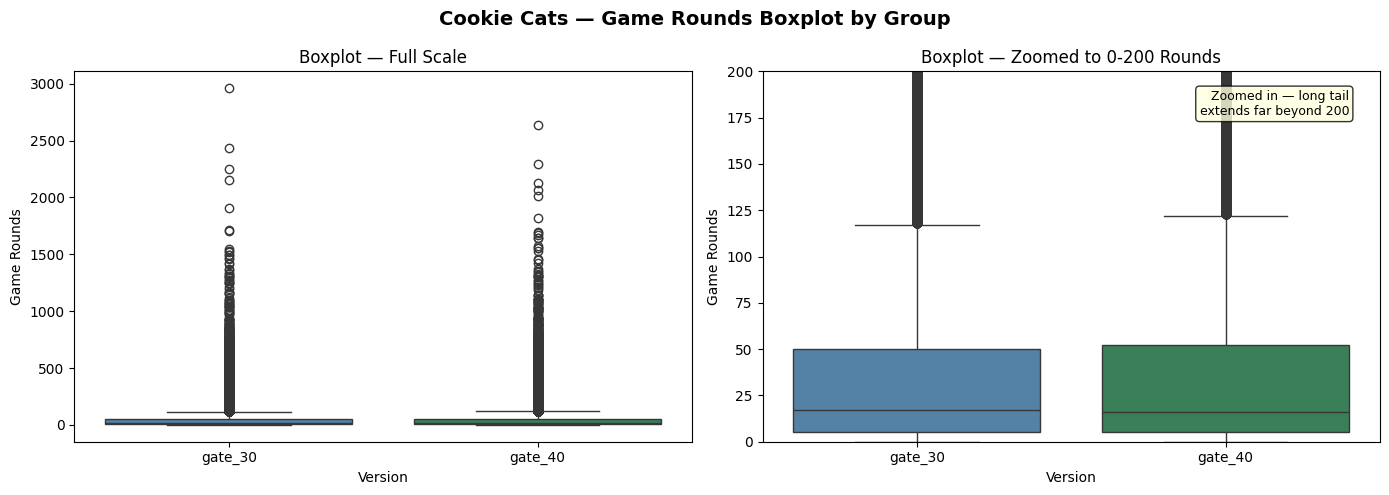

Boxplot saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Full scale boxplot ---
sns.boxplot(data=df, x='version', y='sum_gamerounds', 
            palette=['steelblue', 'seagreen'], ax=axes[0])
axes[0].set_title('Boxplot — Full Scale', fontsize=12)
axes[0].set_xlabel('Version')
axes[0].set_ylabel('Game Rounds')

# --- Zoomed in boxplot (better view of the box itself) ---
sns.boxplot(data=df, x='version', y='sum_gamerounds', 
            palette=['steelblue', 'seagreen'], ax=axes[1])
axes[1].set_ylim(0, 200)
axes[1].set_title('Boxplot — Zoomed to 0-200 Rounds', fontsize=12)
axes[1].set_xlabel('Version')
axes[1].set_ylabel('Game Rounds')
axes[1].annotate('Zoomed in — long tail\nextends far beyond 200', 
                 xy=(0.95, 0.95), xycoords='axes fraction',
                 ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Cookie Cats — Game Rounds Boxplot by Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'data', 'phase2_boxplot_by_group.png'), dpi=150)
plt.show()
print("Boxplot saved.")

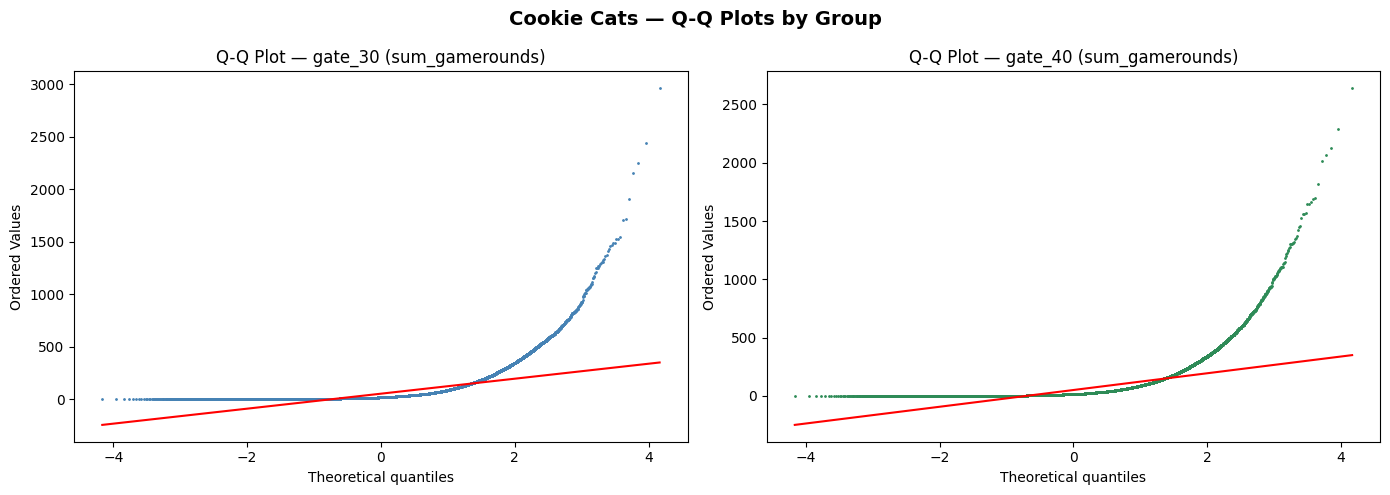

Q-Q plots saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Q-Q plot gate_30 ---
stats.probplot(gate_30, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot — gate_30 (sum_gamerounds)', fontsize=12)
axes[0].get_lines()[0].set(color='steelblue', markersize=1)
axes[0].get_lines()[1].set(color='red', linewidth=1.5)

# --- Q-Q plot gate_40 ---
stats.probplot(gate_40, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot — gate_40 (sum_gamerounds)', fontsize=12)
axes[1].get_lines()[0].set(color='seagreen', markersize=1)
axes[1].get_lines()[1].set(color='red', linewidth=1.5)

plt.suptitle('Cookie Cats — Q-Q Plots by Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'data', 'phase2_qq_plots.png'), dpi=150)
plt.show()
print("Q-Q plots saved.")

In [6]:
# --- Sample 5000 per group for Shapiro-Wilk ---
# (Full sample makes Shapiro-Wilk oversensitive on large n)
np.random.seed(42)
sample_30 = gate_30.sample(5000)
sample_40 = gate_40.sample(5000)

# --- Run Shapiro-Wilk ---
stat_30, p_30 = stats.shapiro(sample_30)
stat_40, p_40 = stats.shapiro(sample_40)

print("=== Shapiro-Wilk Normality Test ===")
print(f"\ngate_30:")
print(f"  W statistic : {stat_30:.6f}")
print(f"  p-value     : {p_30:.6e}")
print(f"  Normal?     : {'Yes' if p_30 > 0.05 else 'No — reject normality'}")

print(f"\ngate_40:")
print(f"  W statistic : {stat_40:.6f}")
print(f"  p-value     : {p_40:.6e}")
print(f"  Normal?     : {'Yes' if p_40 > 0.05 else 'No — reject normality'}")

print("""
--- Interpretation ---
Shapiro-Wilk tests the null hypothesis that the data is normally distributed.
p-value < 0.05 → reject normality.

Note: We sampled 5,000 per group instead of using the full dataset.
On very large samples (n > 5,000), Shapiro-Wilk almost always rejects 
normality even for near-normal data — the test becomes oversensitive.
Visual evidence from histograms and Q-Q plots is equally important here.

Both the visual plots (heavy right skew, curved Q-Q plots) and the 
Shapiro-Wilk test together confirm: sum_gamerounds is NOT normally 
distributed in either group.
""")

=== Shapiro-Wilk Normality Test ===

gate_30:
  W statistic : 0.494608
  p-value     : 2.214449e-80
  Normal?     : No — reject normality

gate_40:
  W statistic : 0.519751
  p-value     : 2.794924e-79
  Normal?     : No — reject normality

--- Interpretation ---
Shapiro-Wilk tests the null hypothesis that the data is normally distributed.
p-value < 0.05 → reject normality.

Note: We sampled 5,000 per group instead of using the full dataset.
On very large samples (n > 5,000), Shapiro-Wilk almost always rejects 
normality even for near-normal data — the test becomes oversensitive.
Visual evidence from histograms and Q-Q plots is equally important here.

Both the visual plots (heavy right skew, curved Q-Q plots) and the 
Shapiro-Wilk test together confirm: sum_gamerounds is NOT normally 
distributed in either group.



In [7]:
# --- Mann-Whitney U Test ---
u_stat, p_value = stats.mannwhitneyu(gate_30, gate_40, alternative='two-sided')

# --- Effect size: rank-biserial correlation ---
# Formula: r = 1 - (2U / (n1 * n2))
n1 = len(gate_30)
n2 = len(gate_40)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print("=== Mann-Whitney U Test: sum_gamerounds ===")
print(f"\nTest details:")
print(f"  H0          : The distributions of gate_30 and gate_40 are equal")
print(f"  H1          : The distributions are not equal (two-sided)")
print(f"  Sample size : gate_30 = {n1:,}, gate_40 = {n2:,}")

print(f"\nResults:")
print(f"  U statistic       : {u_stat:,.2f}")
print(f"  p-value           : {p_value:.6f}")
print(f"  Significant?      : {'Yes' if p_value < 0.05 else 'No'} (alpha = 0.05)")

print(f"\nEffect size:")
print(f"  Rank-biserial r   : {rank_biserial:.6f}")
print(f"  Interpretation    : {'Small' if abs(rank_biserial) < 0.1 else 'Medium' if abs(rank_biserial) < 0.3 else 'Large'} effect")
print("""
Effect size benchmarks (rank-biserial):
  |r| < 0.1  → Negligible
  |r| < 0.3  → Small
  |r| < 0.5  → Medium
  |r| >= 0.5 → Large
""")

=== Mann-Whitney U Test: sum_gamerounds ===

Test details:
  H0          : The distributions of gate_30 and gate_40 are equal
  H1          : The distributions are not equal (two-sided)
  Sample size : gate_30 = 44,699, gate_40 = 45,489

Results:
  U statistic       : 1,024,285,761.50
  p-value           : 0.050892
  Significant?      : No (alpha = 0.05)

Effect size:
  Rank-biserial r   : -0.007504
  Interpretation    : Small effect

Effect size benchmarks (rank-biserial):
  |r| < 0.1  → Negligible
  |r| < 0.3  → Small
  |r| < 0.5  → Medium
  |r| >= 0.5 → Large



In [8]:
# --- Contingency table: retention_1 ---
ct_retention_1 = pd.crosstab(df['version'], df['retention_1'])
ct_retention_1.columns = ['Not Retained', 'Retained']

# --- Contingency table: retention_7 ---
ct_retention_7 = pd.crosstab(df['version'], df['retention_7'])
ct_retention_7.columns = ['Not Retained', 'Retained']

print("=== Contingency Table: retention_1 ===")
print(ct_retention_1)
print(f"\nRetention rates:")
print(f"  gate_30: {ct_retention_1.loc['gate_30', 'Retained'] / ct_retention_1.loc['gate_30'].sum():.4f}")
print(f"  gate_40: {ct_retention_1.loc['gate_40', 'Retained'] / ct_retention_1.loc['gate_40'].sum():.4f}")

print("\n=== Contingency Table: retention_7 ===")
print(ct_retention_7)
print(f"\nRetention rates:")
print(f"  gate_30: {ct_retention_7.loc['gate_30', 'Retained'] / ct_retention_7.loc['gate_30'].sum():.4f}")
print(f"  gate_40: {ct_retention_7.loc['gate_40', 'Retained'] / ct_retention_7.loc['gate_40'].sum():.4f}")

=== Contingency Table: retention_1 ===
         Not Retained  Retained
version                        
gate_30         24665     20034
gate_40         25370     20119

Retention rates:
  gate_30: 0.4482
  gate_40: 0.4423

=== Contingency Table: retention_7 ===
         Not Retained  Retained
version                        
gate_30         36198      8501
gate_40         37210      8279

Retention rates:
  gate_30: 0.1902
  gate_40: 0.1820


In [9]:
# --- Chi-square test: retention_1 ---
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(ct_retention_1)

# --- Chi-square test: retention_7 ---
chi2_7, p7, dof7, expected7 = stats.chi2_contingency(ct_retention_7)

# --- Cramer's V effect size ---
def cramers_v(chi2, n, k):
    """
    chi2 : chi-square statistic
    n    : total sample size
    k    : min(rows, cols) - 1
    """
    return np.sqrt(chi2 / (n * k))

n = len(df)
cramers_v_1 = cramers_v(chi2_1, n, 1)
cramers_v_7 = cramers_v(chi2_7, n, 1)

# --- Absolute percentage point difference ---
pp_diff_1 = abs(0.4482 - 0.4423)
pp_diff_7 = abs(0.1902 - 0.1820)

print("=== Chi-Square Test: retention_1 ===")
print(f"  H0               : Retention rate is independent of game version")
print(f"  Chi2 statistic   : {chi2_1:.4f}")
print(f"  Degrees of freed : {dof1}")
print(f"  p-value          : {p1:.6f}")
print(f"  Significant?     : {'Yes' if p1 < 0.05 else 'No'} (alpha = 0.05)")
print(f"  Cramer's V       : {cramers_v_1:.6f}")
print(f"  % point diff     : {pp_diff_1:.4f} ({pp_diff_1*100:.2f} pp)")

print("\n=== Chi-Square Test: retention_7 ===")
print(f"  H0               : Retention rate is independent of game version")
print(f"  Chi2 statistic   : {chi2_7:.4f}")
print(f"  Degrees of freed : {dof7}")
print(f"  p-value          : {p7:.6f}")
print(f"  Significant?     : {'Yes' if p7 < 0.05 else 'No'} (alpha = 0.05)")
print(f"  Cramer's V       : {cramers_v_7:.6f}")
print(f"  % point diff     : {pp_diff_7:.4f} ({pp_diff_7*100:.2f} pp)")

print("""
Effect size benchmarks (Cramer's V):
  V < 0.1  → Negligible
  V < 0.3  → Small
  V < 0.5  → Medium
  V >= 0.5 → Large
""")

=== Chi-Square Test: retention_1 ===
  H0               : Retention rate is independent of game version
  Chi2 statistic   : 3.1698
  Degrees of freed : 1
  p-value          : 0.075010
  Significant?     : No (alpha = 0.05)
  Cramer's V       : 0.005928
  % point diff     : 0.0059 (0.59 pp)

=== Chi-Square Test: retention_7 ===
  H0               : Retention rate is independent of game version
  Chi2 statistic   : 9.9153
  Degrees of freed : 1
  p-value          : 0.001639
  Significant?     : Yes (alpha = 0.05)
  Cramer's V       : 0.010485
  % point diff     : 0.0082 (0.82 pp)

Effect size benchmarks (Cramer's V):
  V < 0.1  → Negligible
  V < 0.3  → Small
  V < 0.5  → Medium
  V >= 0.5 → Large



In [11]:
interpretation = """
╔══════════════════════════════════════════════════════════════════╗
║           PHASE 2 — STATISTICAL RESULTS & INTERPRETATION         ║
║           Cookie Cats A/B Test                                   ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPERIMENT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Control   : gate_30 — gate appears at level 30 (n = 44,699)
  Treatment : gate_40 — gate appears at level 40 (n = 45,489)
  Question  : Does moving the gate from level 30 to level 40
              affect player engagement and retention?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEST SELECTION RATIONALE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  sum_gamerounds (continuous):
    - Shapiro-Wilk W = 0.49/0.52, p ≈ 10^-80 → not normal
    - Histograms and Q-Q plots confirm heavy right skew
    - Decision: Mann-Whitney U test (non-parametric)
    - Reason: does not assume normality, compares rank
              distributions rather than means

  retention_1, retention_7 (binary):
    - Outcomes are categorical (retained: yes/no)
    - Data structured as counts in a 2x2 table
    - Decision: Chi-square test
    - Reason: tests whether retention outcome is independent
              of group assignment

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OUTCOME 1: sum_gamerounds (Engagement)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test            : Mann-Whitney U
  U statistic     : 1,024,285,761.50
  p-value         : 0.0509
  Significant?    : No (just above alpha = 0.05)
  Effect size     : Rank-biserial r = -0.0075 (Negligible)
  gate_30 median  : 17.0 rounds
  gate_40 median  : 16.0 rounds

  Interpretation:
  Moving the gate from level 30 to level 40 produced no
  statistically significant difference in how many game
  rounds players played (p = 0.051). Even had it crossed
  the significance threshold, the effect size is negligible
  (r = -0.0075). The gate position does not meaningfully
  affect player engagement as measured by rounds played.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OUTCOME 2: retention_1 (1-Day Retention)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test            : Chi-Square
  Chi2 statistic  : 3.1698
  p-value         : 0.0750
  Significant?    : No (above alpha = 0.05)
  Effect size     : Cramer's V = 0.0059 (Negligible)
  gate_30 rate    : 44.82%
  gate_40 rate    : 44.23%
  Difference      : 0.59 percentage points

  Interpretation:
  There is no statistically significant difference in
  1-day retention between groups (p = 0.075). The
  0.59 percentage point difference in favor of gate_30
  is well within the range of random chance. Moving the
  gate did not meaningfully affect whether players
  returned the next day.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OUTCOME 3: retention_7 (7-Day Retention)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test            : Chi-Square
  Chi2 statistic  : 9.9153
  p-value         : 0.0016
  Significant?    : Yes (well below alpha = 0.05)
  Effect size     : Cramer's V = 0.0105 (Negligible)
  gate_30 rate    : 19.02%
  gate_40 rate    : 18.20%
  Difference      : 0.82 percentage points

  Interpretation:
  7-day retention is statistically significantly higher
  for gate_30 than gate_40 (p = 0.0016). However the
  effect size is negligible (Cramer's V = 0.0105) and
  the absolute difference is only 0.82 percentage points.
  While this result is real and not due to chance, its
  practical importance is limited. At scale (90,000+
  players), even tiny differences become detectable —
  this is a textbook example of why effect size must
  accompany significance testing.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OVERALL RECOMMENDATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  The evidence modestly favors keeping the gate at level 30.
  It is the only condition that shows a statistically
  significant advantage (7-day retention), and gate_30
  outperforms gate_40 on all three metrics. However the
  effects are small — this is not a dramatic win, and
  business context (e.g., monetization, player complaints
  about the gate) should factor into the final decision
  alongside these statistical results.
"""

print(interpretation)

# --- Save to file ---
interp_path = os.path.join(project_root, 'data', 'phase2_interpretation.txt')
with open(interp_path, 'w', encoding='utf-8') as f:
    f.write(interpretation)

print("Interpretation saved to:", interp_path)


╔══════════════════════════════════════════════════════════════════╗
║           PHASE 2 — STATISTICAL RESULTS & INTERPRETATION         ║
║           Cookie Cats A/B Test                                   ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPERIMENT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Control   : gate_30 — gate appears at level 30 (n = 44,699)
  Treatment : gate_40 — gate appears at level 40 (n = 45,489)
  Question  : Does moving the gate from level 30 to level 40
              affect player engagement and retention?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEST SELECTION RATIONALE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  sum_gamerounds (continuous):
    - Shapiro-Wilk W = 0.49/0.52, p ≈ 10^-80 → not normal
    - Histograms and Q-Q plots confirm heavy right skew
    - Decision: Mann-Whitney 